Install Library

In [ ]:
!pip install catboost imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.7 MB/s eta 0:00:00


Import

In [ ]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

Dataset Load

In [ ]:
df = pd.read_csv("/content/online_shoppers_intention.csv")

# Inspect dataset
print(df.head())
print(df.info())
print(df.isnull().sum())

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         0.0   Feb   

In [ ]:
# Encode target
df['Revenue'] = df['Revenue'].astype(int)

Feature Engineering

In [ ]:
df['TotalPageDuration'] = df['Administrative_Duration'] + df['ProductRelated_Duration'] + df['Informational_Duration']
df['ProductPagesRatio'] = df['ProductRelated'] / (df['Administrative'] + df['Informational'] + df['ProductRelated'] + 1e-5)  # avoid division by zero
df['BounceExitInteraction'] = df['BounceRates'] * df['ExitRates']
df['PageValueProduct'] = df['PageValues'] * df['ProductRelated_Duration']

In [ ]:
#Identify features
categorical_features = ['Month', 'VisitorType', 'Weekend']
target = 'Revenue'
X = df.drop(columns=[target])
y = df[target]

Train and Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Catboost model implementation

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# categorical feature indices
cat_features = [X_train.columns.get_loc(c)
                for c in X_train.select_dtypes(include=['object']).columns]

# class weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

cat = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    iterations=1000,
    early_stopping_rounds=50,
    verbose=0,
    cat_features=cat_features,
    class_weights=weights
)

param_dist = {
    'depth': [6, 8, 10],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [3, 5, 7, 9],
    'bagging_temperature': [0, 0.5, 1],
}

search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best AUC (CV):", search.best_score_)



Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'learning_rate': 0.03, 'l2_leaf_reg': 9, 'depth': 6, 'bagging_temperature': 0.5}
Best AUC (CV): 0.9283537503144483


Testing

In [ ]:
from catboost import CatBoostClassifier

best_cat = CatBoostClassifier(
    **search.best_params_,
    loss_function='Logloss',
    eval_metric='AUC',     # keep consistent
    cat_features=cat_features,
    class_weights=weights,
    verbose=200
)

best_cat.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),   # or X_val, y_val if you split
    early_stopping_rounds=100
)



0:	test: 0.8792822	best: 0.8792822 (0)	total: 27ms	remaining: 27s
200:	test: 0.9308054	best: 0.9309285 (188)	total: 3.33s	remaining: 13.2s
400:	test: 0.9305692	best: 0.9310478 (323)	total: 6.04s	remaining: 9.02s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9310478239
bestIteration = 323

Shrink model to first 324 iterations.


Model results

In [ ]:
from catboost import CatBoostClassifier, Pool

# Build CatBoost Pools
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_features
)

# Create model
best_cat = CatBoostClassifier(
    **search.best_params_,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=weights,
    random_seed=42,
    verbose=200
)

# Fit model (THIS must succeed)
best_cat.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=100
)
print("Model fitted:", best_cat.is_fitted())
print("Trees:", best_cat.tree_count_)

y_pred = best_cat.predict(X_test)
y_proba = best_cat.predict_proba(X_test)[:, 1]
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n--- Model Performance (CatBoost) ---")
print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1-Score  :", f1_score(y_test, y_pred))
print("ROC-AUC   :", roc_auc_score(y_test, y_proba))


0:	test: 0.8680108	best: 0.8680108 (0)	total: 66.7ms	remaining: 1m 6s
200:	test: 0.9302024	best: 0.9302075 (199)	total: 7.71s	remaining: 30.6s
400:	test: 0.9304863	best: 0.9311182 (314)	total: 13.9s	remaining: 20.7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9311181678
bestIteration = 314

Shrink model to first 315 iterations.
Model fitted: True
Trees: 315

--- Model Performance (CatBoost) ---
Accuracy  : 0.8625304136253041
Precision : 0.5362563237774031
Recall    : 0.8324607329842932
F1-Score  : 0.6523076923076923
ROC-AUC   : 0.9311181678407413


Feature Importance (CatBoost)

In [ ]:
feature_importances = best_cat.get_feature_importance(prettified=True)

print("\n--- Feature Importance (CatBoost) ---")
print(feature_importances)



--- Feature Importance (CatBoost) ---
                 Feature Id  Importances
0                     Month    25.851192
1                PageValues    24.392593
2          PageValueProduct    11.849351
3                 ExitRates     4.383811
4         TotalPageDuration     3.625304
5         ProductPagesRatio     3.302264
6               VisitorType     3.169407
7   ProductRelated_Duration     3.070368
8     BounceExitInteraction     2.489230
9   Administrative_Duration     2.374072
10              TrafficType     2.240409
11           ProductRelated     2.158078
12           Administrative     1.938067
13               SpecialDay     1.721488
14              BounceRates     1.715334
15                   Region     1.179397
16                  Weekend     1.060362
17         OperatingSystems     1.054705
18            Informational     1.043990
19   Informational_Duration     0.766608
20                  Browser     0.613971


Feature Importance representation

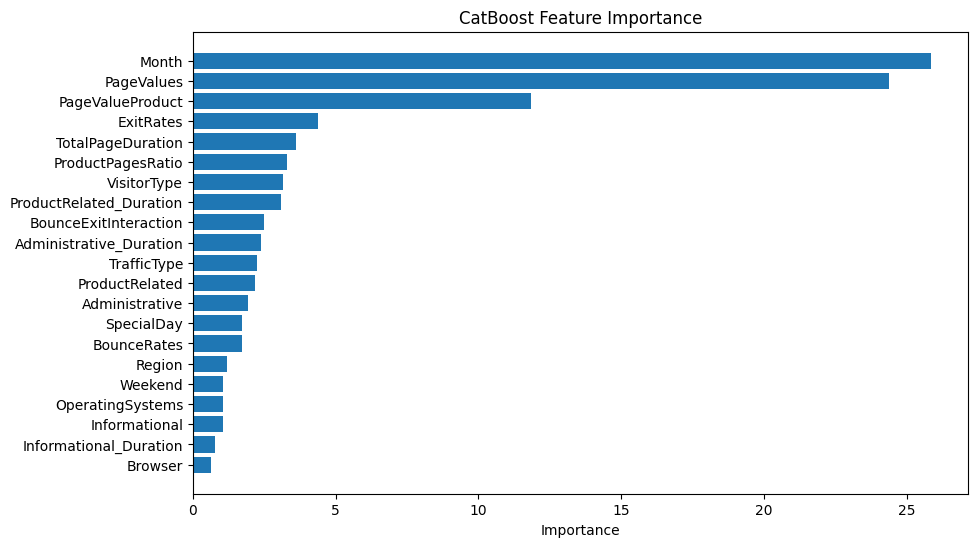

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances (prettified=True returns a DataFrame with 'Feature Id' and 'Importances')
feature_importances = best_cat.get_feature_importance(prettified=True)

# Optional: rename columns for clarity
feature_importances.columns = ["Feature", "Importance"]

# Sort descending
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importances["Feature"], feature_importances["Importance"])
plt.gca().invert_yaxis()  # Highest importance on top
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.show()



Saving Results

In [ ]:
import sys

# Define output file
output_file = "full_results.txt"

# Redirect stdout to file
with open(output_file, "w") as f:
    # Save original stdout
    old_stdout = sys.stdout
    sys.stdout = f

    # ---------------------------
    # Your code block goes here
    # ---------------------------
    print("\n--- Model Performance (CatBoost) ---")
    print("Accuracy  :", accuracy_score(y_test, y_pred))
    print("Precision :", precision_score(y_test, y_pred))
    print("Recall    :", recall_score(y_test, y_pred))
    print("F1-Score  :", f1_score(y_test, y_pred))
    print("ROC-AUC   :", roc_auc_score(y_test, y_proba))

    print("\n--- Feature Importance ---")
    print(feature_importances)

    # You can add any other print statements here

    # Restore original stdout
    sys.stdout = old_stdout

print(f"All results saved to {output_file}")


All results saved to full_results.txt
